In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
using Observers #for TDVP
using DSP #for LB calculations

In [ ]:
"""
Struct definitions for parameters
"""

Base.@kwdef struct BathParameters
    Γ::Float64 #Coupling to system
    β::Float64 #inverse temperature
    μ::Float64 #chemical potential
    D::Float64 #bandwidth
    N::Int     #Number of chain modes
end

Base.@kwdef struct SystemParameters
    ϵ::Vector{Float64} #Vector of onsite energies
    t::Vector{Float64} #Vector of couplings
    U::Vector{Float64} #Vector of interactions
    occupations::Vector{String} # Vector of initial occupations
end

Base.@kwdef struct TDVP_parameters
    tdvp_cutoff::Float64 #Numerical cutoff for tdvp
    minbonddim::Int      #Minimum bond dimension for tdvp
    maxbonddim::Int      #Maximum bond dimension for tdvp
    δt::Float64          #Time step
    total_simulation_time::Float64 #Evolution time
end


abstract type ThermofieldSector end
struct Filled <: ThermofieldSector end
struct Empty <: ThermofieldSector end

struct ChainLayout

    left_filled
    left_empty

    system

    right_filled
    right_empty
end


"""
Initialisation functions
"""

fermi_factor(ω,β,μ) = 1 / (exp(β*(ω-μ)) + 1)
heaviside(t) = 0.5 * (sign.(t) .+ 1)

function semicircular_density(Γ,ω,D)
    J = real((2*Γ/(π^2))*sqrt.(Complex.(1 .-(ω/D).^2)))
    return J

end

function box_spectral_density(Γ,ω,D)
    #Box spectral density
    return J = (Γ/(2*π))*(heaviside(ω .+ D) .- heaviside(ω .- D))
end

function thermofield_spectral_density(ω,bath::BathParameters,::Filled)
    #Spectral density for a filled chain
    J = box_spectral_density(bath.Γ,ω,bath.D)
   # J = semicircular_density(bath.Γ,ω,bath.D)
    return J * fermi_factor(ω,bath.β,bath.μ)
end

function thermofield_spectral_density(ω,bath::BathParameters,::Empty)
    #Spectral density for an empty chain
    J = box_spectral_density(bath.Γ,ω,bath.D)
  #  J = semicircular_density(bath.Γ,ω,bath.D)
    return J * (1 - fermi_factor(ω,bath.β,bath.μ))
end

function chain_mapping(bath::BathParameters,sector::ThermofieldSector)

    #Calculates the chain coefficients using PolyChaos.jl

    spec_fun(ω) = thermofield_spectral_density(ω,bath,sector)

    #support needs to be larger than spectral function for numerical reasons.
    support = (-2*bath.D,2*bath.D)

    meas = Measure("thermofield",spec_fun,support,false,Dict())
    op = OrthoPoly("chain",bath.N-1,meas;Nquad=100000)

    α = coeffs(op)[:,1]
    β = coeffs(op)[:,2]

    return α,sqrt.(β)
end

function ChainLayout(N_left_bath,N_right_bath,Nsys)
    ##Arranges the chains in interleaved fashion, with the system at the centre. Any
    ##other layout can be encoded here and will follow through to the rest of the code.

    N = 2*(N_left_bath+N_right_bath) + Nsys

    ChainLayout(
        1:2:2*N_left_bath,
        2:2:2*N_left_bath,
        2*N_left_bath+1:2*N_left_bath+Nsys,
        2*N_left_bath+Nsys+1:2:N,
        2*N_left_bath+Nsys+2:2:N,
    )
end

function add_chain(H,os,inds,energies,hoppings)
    ##Adds MPO terms and associated single particle hamiltonian elements 
    ##for the thermofield chain

    N = length(inds)
    for i in 1:N
        os += energies[i],"N",inds[i]

        H[inds[i],inds[i]] = energies[i]

        if i < N
            t = hoppings[i]
            os += t,"Cdag",inds[i],"C",inds[i+1]
            os += t,"Cdag",inds[i+1],"C",inds[i]

            H[inds[i],inds[i+1]] = t
            H[inds[i+1],inds[i]] = t
        end
    end
    return H,os
end

function couple_sites(H,os,i,j,t)
    #Couples two sites, used for the system-chain coupling

    os += t,"Cdag",i,"C",j
    os += t,"Cdag",j,"C",i

    H[i,j] = t
    H[j,i] = t
    return H,os
end

function build_hamiltonian(sites,left,right,sys)
    #builds single particle hamiltonian and many body MPO

    layout =ChainLayout(left.N,right.N,length(sys.ϵ))
    N = length(sites)
    Hsingle = zeros(ComplexF64,N,N)
    os = OpSum()

    #chain coefficients for the four chains
    εLF,tLF =chain_mapping(left,Filled())
    εLE,tLE =chain_mapping(left,Empty())
    εRF,tRF =chain_mapping(right,Filled())
    εRE,tRE =chain_mapping(right,Empty())

    #adds the terms for the chains
    Hsingle,os = add_chain(Hsingle,os,layout.left_filled,reverse(εLF),reverse(tLF))
    Hsingle,os = add_chain(Hsingle,os,layout.left_empty,reverse(εLE),reverse(tLE))
    Hsingle,os = add_chain(Hsingle,os,layout.right_filled,εRF,tRF[2:end])
    Hsingle,os = add_chain(Hsingle,os,layout.right_empty,εRE,tRE[2:end])


    #
    # system
    #

    for i in eachindex(sys.ϵ)
        ##energies
        os += sys.ϵ[i],"N",layout.system[i]
        Hsingle[layout.system[i],layout.system[i]] = sys.ϵ[i]
        if i < length(sys.ϵ)
            #hoppings
            Hsingle,os = couple_sites(Hsingle,os,layout.system[i],layout.system[i+1],sys.t[i])
            #interactions
            os += sys.U[i],"N",layout.system[i],"N",layout.system[i+1]
        end
    end

    #
    # bath-system couplings
    #

    Hsingle,os = couple_sites(Hsingle,os,last(layout.left_filled),first(layout.system),first(tLF))
    Hsingle,os = couple_sites(Hsingle,os,last(layout.left_empty),first(layout.system),first(tLE))
    Hsingle,os = couple_sites(Hsingle,os,first(layout.right_filled),last(layout.system),first(tRF))
    Hsingle,os = couple_sites(Hsingle,os,first(layout.right_empty),last(layout.system),first(tRE))
    return MPO(os,sites), Hsingle
end

function thermofield_state(left,right,system)
    #defines the initial state given both baths have an interleaved ordering
    #for the filled and empty chains. Both start with the filled mode from the left.

    layout =ChainLayout(left.N,right.N,length(system.ϵ))
    N = 2*(left.N+right.N)+length(system.ϵ)
    
    occs = Vector{String}(undef,N)
    occs[layout.left_filled] .= "Occ"
    occs[layout.left_empty] .= "Emp"
    occs[layout.right_filled] .= "Occ"
    occs[layout.right_empty] .="Emp"
    occs[layout.system] = system.occupations

    return occs
end

#Evolution functions

function current_time(; current_time, bond, half_sweep)
    if bond == 1 && half_sweep == 2
    return real(im*current_time)
    end
    return nothing
end
function measure_correlation_matrix(; state, bond, half_sweep)
    if bond==1 && half_sweep == 2
        return correlation_matrix(state,"Cdag","C")
    end
    return nothing
end
function propagate_correlations(corr0,Hsingle,times)
    
    """
    The correlation matrix C_ij = expect(cdag[j]*c[i]) propagates according to
    C_ij(t) =U*C_ij(0)*U', but G_ij = expect(cdag[i]*c[j]) doesn't.
    
    # This is also why the returned correlation matrices are transposed, as we want the output to be the standard definition
    # G_ij = expect(cdag[i]*c[j]).
    """

    δt = times[2] - times[1]
    U_step = exp(-im*δt*Hsingle)

    corrs = Vector{Any}(undef,length(times))
    corrs[1] = U_step*corr0*U_step'
    for i in 2:length(times)
        corrs[i] = U_step*corrs[i-1]*U_step'
    end
    return transpose.(corrs)
end
function LB_current(left,right,system)
    
    """
    Calculates the steady state particle current Jp of a system 
    using the Landauer-Büttiker formalism. This assumes both baths have the same spectral function, given by the box function.
    """

    eta = 0.005 
    wsamp = 10000; # Frequency sampling.
    w = range(-10*left.D,10*left.D,wsamp); # Frequency axis for Landauer calculations (larger than the band).
    Γ = left.Γ+right.Γ
    dw = w[2] - w[1]; # Frequency increment.


    ρ = (1/(2*left.D))*(heaviside(w .+ left.D) .- heaviside(w .- left.D))
    Δ_L = (-left.Γ/(2*π))*log.((w.-left.D .+im*eta)./(w .+left.D .+im*eta))    #exact result (only valid for box)
    Δ_R = (-right.Γ/(2*π))*log.((w.-right.D .+im*eta)./(w .+right.D .+im*eta)) #exact result (only valid for box)
        Δ_L = -im*left.D*left.Γ*hilbert(ρ) #more generally
        Δ_R = -im*left.D*right.Γ*hilbert(ρ) #more generally


    ####Calculate determinant of M matrix (N_sys x N_sys)
    N_sys = length(system.ϵ)
    if N_sys == 1
        Δ = Δ_L + Δ_R
        detM = w .- system.ϵ[1] .- Δ
        G = 1 ./detM
        A_den = (-1/π).*imag.(G)    
    elseif N_sys == 2
        detM = (w .-system.ϵ[1] .-Δ_L).*(w.-system.ϵ[2].-Δ_R)
        detM = detM .- abs.(system.t[1]^2) 
        G = ((w .-system.ϵ[2] .-Δ_R))./detM
        A_den = (-1/π).*imag.(G)    
    elseif N_sys == 3
        detM = (w .-system.ϵ[1] .-Δ_L).*(w.-system.ϵ[3].-Δ_R).*(w.-system.ϵ[2])
        detM = detM - (abs.(system.t[2])^2)*(w.-system.ϵ[1].-Δ_L)
        detM = detM - (abs.(system.t[1])^2)*(w.-system.ϵ[3].-Δ_R)
        G =  (w .-system.ϵ[1] .-Δ_L).*(w.-system.ϵ[3].-Δ_R)./detM
        A_den = (-1/π)*imag.(G)
    end

    A = (left.D*Γ*ρ/π) ./(abs.(detM).^2)
    if length(system.t)>0
        coupling_factor = prod(abs.(system.t).^2)
        A = A.*coupling_factor
    end    
    f_L = fermi_factor.(w,left.β,left.μ)
    f_R = fermi_factor.(w,right.β,right.μ)

    prefactor = (4*π*left.D*left.Γ*right.Γ)/(2*π*Γ)
    Jp = prefactor*sum(ρ.*A.*(f_L - f_R))*dw;

    return Jp
end

function particle_current(site,corr,hopping_term)
    #measures the current from site to site+1
    return real.(2*im*hopping_term*corr[site,site+1])
end
function density(site,corr)
    #measures density at site
    return real(corr[site,site])
end

density (generic function with 1 method)

In [ ]:

"""
Define parameters
"""

left_bath = BathParameters(Γ = 0.5,β = 10.0,μ = 0.1,D = 1.0,N =7)

right_bath = BathParameters(Γ = 0.5,β = 10.0,μ = -0.1,D = 1.0,N = 7)

system = SystemParameters(ϵ = [0.0,0.0],t = [0.1],U = [0.0],occupations=["Occ","Emp"])

time_evolution = TDVP_parameters(tdvp_cutoff = 1e-10,minbonddim = 5,maxbonddim = 20,δt = 0.1,total_simulation_time = 10)

times = range(time_evolution.δt,stop = time_evolution.total_simulation_time,step = time_evolution.δt)

"""
Create initial MPS
"""
sites = siteinds("Fermion",2*left_bath.N+2*right_bath.N + length(system.ϵ);conserve_qns=true)
initial_occupations = thermofield_state(left_bath,right_bath,system)
ψ0 = MPS(ComplexF64,sites,initial_occupations)

"""
Create single particle Hamiltonian and many-body MPO
"""

H_MPO,Hsingle =build_hamiltonian(sites,left_bath,right_bath,system);

"""
TDVP
"""

#create observer for tdvp
obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

#enrichment, needed to reduce initial projection error
alg = "global_krylov"
ψ0 = expand(ψ0,H_MPO;alg = "global_krylov")    


ψT = tdvp(H_MPO, -im * time_evolution.total_simulation_time, ψ0; 
time_step = -im * time_evolution.δt,
cutoff = time_evolution.tdvp_cutoff, 
mindim = time_evolution.minbonddim, 
maxdim = time_evolution.maxbonddim, 
outputlevel = 1, 
observer! = obs)


"""
Exact correlation matrix evolution (only valid for U=0)
"""
corr0 = correlation_matrix(ψ0,"Cdag","C")
exact_corrs = propagate_correlations(corr0,Hsingle,times);

After sweep 1: maxlinkdim=5 maxerr=7.77E-16 current_time=0.0 - 0.1im time=0.231
After sweep 2: maxlinkdim=5 maxerr=6.35E-15 current_time=0.0 - 0.2im time=1.177
After sweep 3: maxlinkdim=5 maxerr=9.29E-14 current_time=0.0 - 0.3im time=1.573
After sweep 4: maxlinkdim=5 maxerr=5.89E-13 current_time=0.0 - 0.4im time=1.633
After sweep 5: maxlinkdim=5 maxerr=2.40E-12 current_time=0.0 - 0.5im time=1.615
After sweep 6: maxlinkdim=5 maxerr=7.47E-12 current_time=0.0 - 0.6im time=1.594
After sweep 7: maxlinkdim=5 maxerr=1.93E-11 current_time=0.0 - 0.7im time=1.59
After sweep 8: maxlinkdim=5 maxerr=4.35E-11 current_time=0.0 - 0.8im time=1.608
After sweep 9: maxlinkdim=5 maxerr=8.85E-11 current_time=0.0 - 0.9im time=1.629
After sweep 10: maxlinkdim=6 maxerr=8.34E-11 current_time=0.0 - 1.0im time=1.621
After sweep 11: maxlinkdim=6 maxerr=6.17E-11 current_time=0.0 - 1.1im time=2.217
After sweep 12: maxlinkdim=7 maxerr=2.01E-11 current_time=0.0 - 1.2im time=1.693
After sweep 13: maxlinkdim=7 maxerr=4.

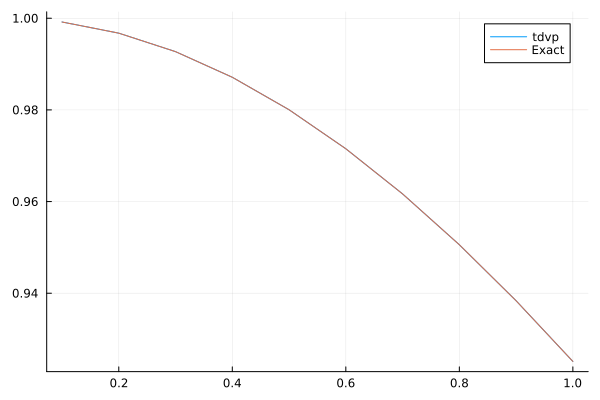

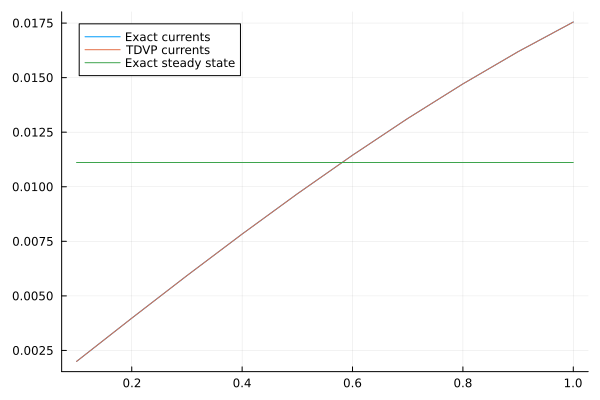

In [14]:
"""
Plotting
"""
#site to look at for density/current
sys_site = 1
MPS_site = 2*left_bath.N+sys_site

tdvp_den = [density(MPS_site,corr) for corr in obs.corr] 
tdvp_currents = [particle_current(MPS_site,corr,system.t[sys_site]) for corr in obs.corr]

exact_den = [density(MPS_site,corr) for corr in exact_corrs]
exact_currents = [particle_current(MPS_site,corr,system.t[sys_site]) for corr in exact_corrs]


plot(times,real.(tdvp_den),label="tdvp")
display(plot!(times,real.(exact_den),label="Exact"))


plot(times,exact_currents,label="Exact currents")
plot!(times,tdvp_currents,label="TDVP currents")
display(plot!(times,real.(LB_current(left_bath,right_bath,system)*ones(length(times))),label="Exact steady state"))